# Calls exploration (cross-platform)

Same as `explore_calls.ipynb`, but picks paths automatically based on the
host OS so it runs on both a local Mac and the Flatiron cluster.

- **Mac (Darwin)**: reads/writes the Dropbox `parquet_cache/`, saves figures to Dropbox `Figures/`.
- **Cluster (Linux)**: reads CSVs from ceph at `gily_data/Processed_data/Audio/all_calls/`, auto-builds a `parquet_cache/` alongside them on first run, and skips writing figures to disk (just shows inline).


In [1]:
import platform
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Platform-aware paths ---------------------------------------------------
HOST = platform.system()  # "Darwin" on Mac, "Linux" on the cluster

if HOST == "Darwin":
    DROPBOX = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project")
    DATA_DIR    = DROPBOX / "Data"
    PARQUET_DIR = DATA_DIR / "parquet_cache"
    FIGURES_DIR = DROPBOX / "Figures"
    REPO_ROOT   = Path("/Users/gilyginosar/repos/gerbil_vocalization_analysis")
    SAVE_FIGS   = True
elif HOST == "Linux":
    # On the Flatiron cluster the consolidated CSVs live next to each other in
    # the shared lab ceph dir; build the parquet cache as a sibling subdir.
    DATA_DIR    = Path("/mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Processed_data/Audio/all_calls")
    PARQUET_DIR = DATA_DIR / "parquet_cache"
    FIGURES_DIR = None
    REPO_ROOT   = Path("/mnt/home/gginosar/repos/gerbil_vocalization_analysis")
    SAVE_FIGS   = False
else:
    raise RuntimeError(f"Unsupported platform: {HOST}")

print(f"HOST={HOST}")
print(f"DATA_DIR    = {DATA_DIR}")
print(f"PARQUET_DIR = {PARQUET_DIR}")
print(f"REPO_ROOT   = {REPO_ROOT}")


# --- Auto-build parquet cache if missing -----------------------------------
# Mirrors scripts/cache_calls_to_parquet.py: parses datetimes, stamps
# date_folder + day_in_experiment. Only converts CSVs that don't have a
# parquet sibling yet.
DATETIME_COLS = ("start_time_real", "stop_time_real")

def _build_parquet_from_csv(csv_path: Path, parquet_path: Path) -> None:
    print(f"  caching {csv_path.name} -> {parquet_path.name} ...")
    df_csv = pd.read_csv(csv_path)
    for col in DATETIME_COLS:
        if col in df_csv.columns:
            df_csv[col] = pd.to_datetime(df_csv[col], errors="coerce")
    date_tag = csv_path.stem.replace("all_calls_", "")
    df_csv["date_folder"] = date_tag
    if "start_time_real" in df_csv.columns:
        df_csv["day_in_experiment"] = (
            df_csv["start_time_real"].dt.normalize().rank(method="dense").astype(int)
        )
    df_csv.to_parquet(parquet_path, index=False)

PARQUET_DIR.mkdir(parents=True, exist_ok=True)
for csv_path in sorted(DATA_DIR.glob("all_calls_*.csv")):
    pq = PARQUET_DIR / f"{csv_path.stem}.parquet"
    if not pq.exists():
        _build_parquet_from_csv(csv_path, pq)


HOST=Linux
DATA_DIR    = /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Processed_data/Audio/all_calls
PARQUET_DIR = /mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Processed_data/Audio/all_calls/parquet_cache
REPO_ROOT   = /mnt/home/gginosar/repos/gerbil_vocalization_analysis


In [2]:
# Figure saving — no-op on the cluster (FIGURES_DIR is None there).
if SAVE_FIGS:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    if not SAVE_FIGS:
        return
    fig.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")


In [3]:
# Shared analysis settings — change here, every plotting cell picks them up.
N = 10  # minutes per bin
LIGHT_DEFAULT = (8, 20)
LIGHT_OVERRIDES = {"2026_02": (4, 16)}

# Map raw assigned_location values to the 2-level grouping used by some plots.
LOC_GROUPS = {"arena_1": "arena", "arena_2": "arena", "underground": "underground"}


## What's available?

In [4]:
sorted(p.name for p in PARQUET_DIR.glob("*.parquet"))


['all_calls_2024_12.parquet',
 'all_calls_2025_03.parquet',
 'all_calls_2025_07.parquet',
 'all_calls_2025_10.parquet',
 'all_calls_2026_02.parquet']

## Load one month

Each row is one call. To work with several months at once, load each parquet with `pd.read_parquet(...)` and concatenate them with `pd.concat([...], ignore_index=True)`.

In [ ]:
df = pd.read_parquet(PARQUET_DIR / "all_calls_2025_10.parquet")
df.head()


## Shape and dtypes

In [ ]:
print(df.shape)
df.info()


## A first cut: how many of each call type?

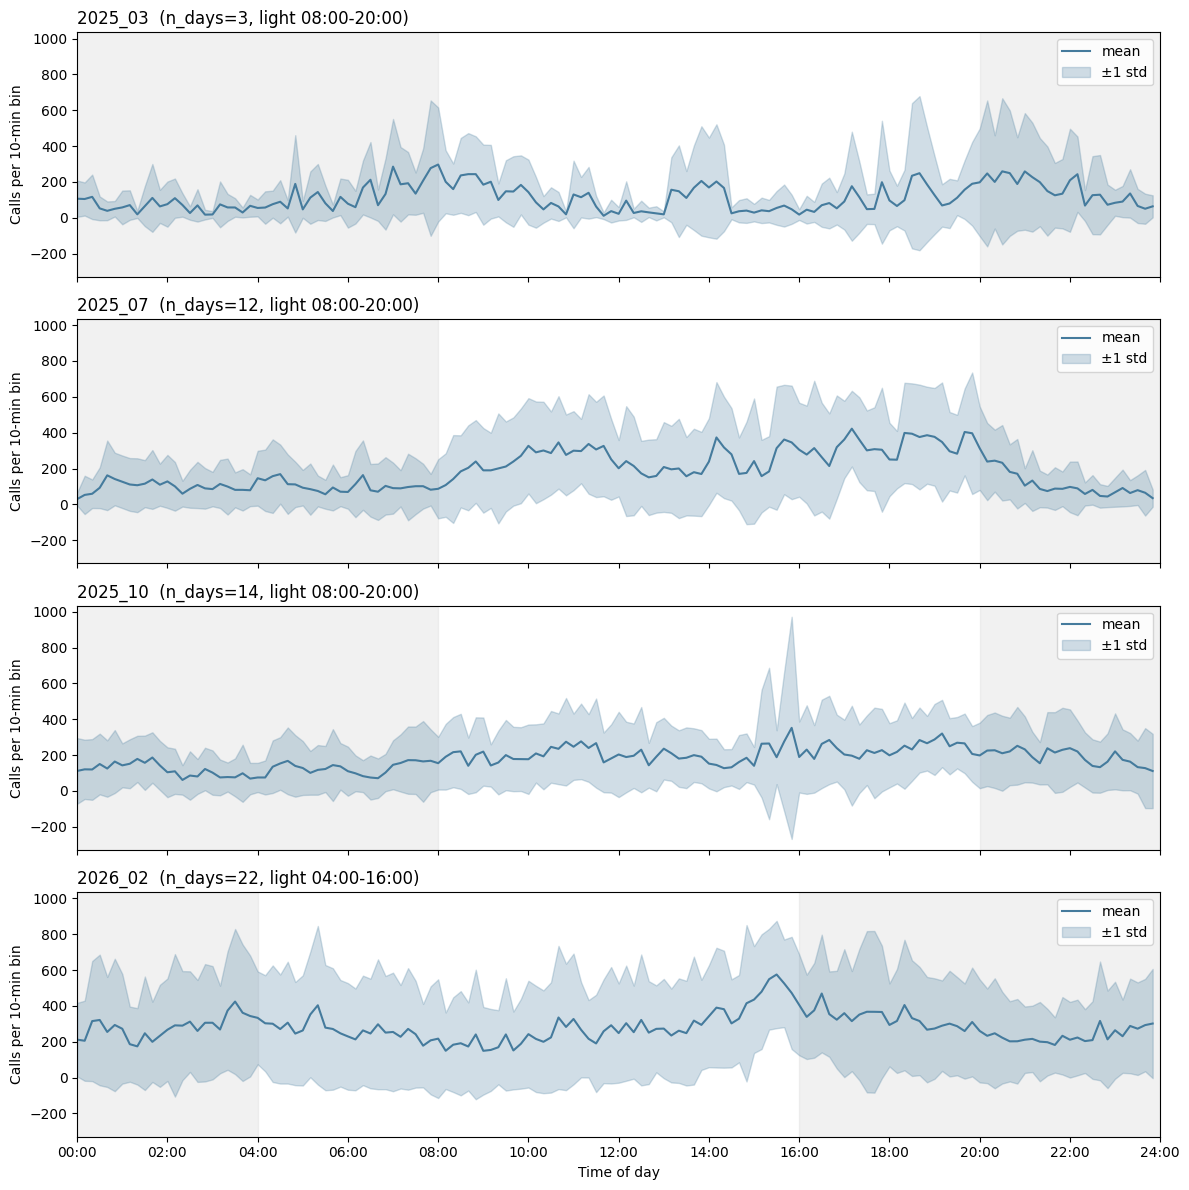

In [5]:
DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(12, 3 * len(DATES_TO_PLOT)),
    sharex=True,
    sharey=True,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    ts = df_d["start_time_real"]
    day = ts.dt.normalize()
    slot = ((ts.dt.hour * 60 + ts.dt.minute) // N) * N

    counts = df_d.groupby([day, slot]).size()
    matrix = counts.unstack(fill_value=0)
    mean = matrix.mean(axis=0)
    std  = matrix.std(axis=0)

    x_hours = mean.index / 60
    ax.plot(x_hours, mean, color="#457B9D", label="mean")
    ax.fill_between(x_hours, mean - std, mean + std, alpha=0.25, color="#457B9D", label="±1 std")

    # Dark hours background — pick this date's light window, fall back to default.
    light_start, light_end = LIGHT_OVERRIDES.get(date_tag, LIGHT_DEFAULT)
    if light_start < light_end:
        ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
        ax.axvspan(light_end, 24, color="lightgray", alpha=0.3, zorder=0)
    else:
        ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

    ax.set_title(f"{date_tag}  (n_days={matrix.shape[0]}, light {light_start:02d}:00-{light_end:02d}:00)", loc="left")
    ax.set_ylabel(f"Calls per {N}-min bin")
    ax.set_xlim(0, 24)
    ax.legend(loc="upper right")

# X-axis labels (only on the bottom subplot since sharex=True).
ticks = range(0, 25, 2)
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f"{h:02d}:00" for h in ticks])
axes[-1].set_xlabel("Time of day")

fig.tight_layout()
plt.show()
save_fig(fig, "calls_per_bin_4dates")


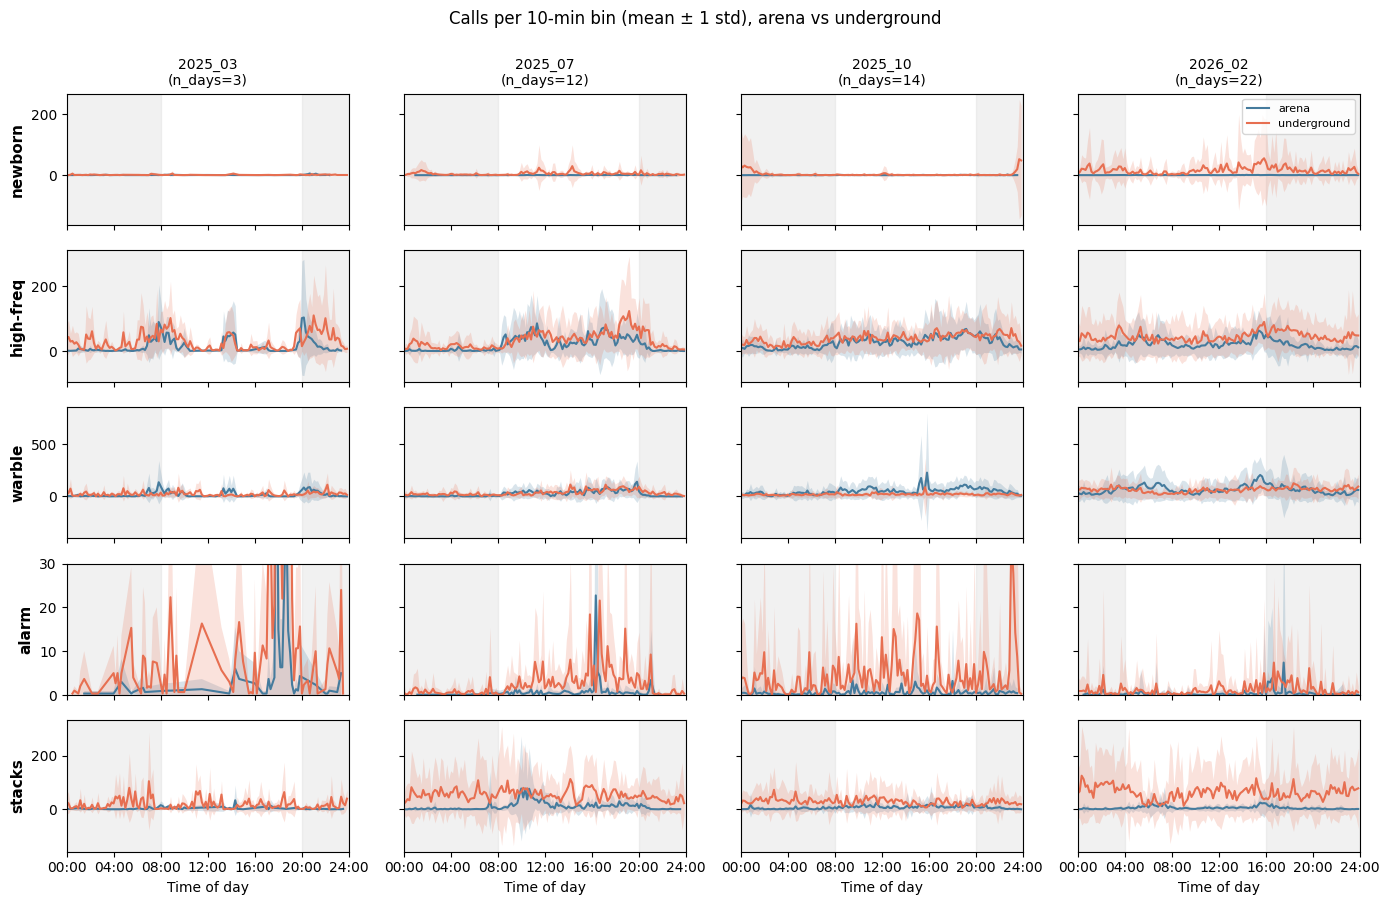

In [6]:
# 5x4 grid (call types x dates), with 2 lines per panel: arena vs underground.
DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]

CALL_TYPE_ORDER = ["newborn", "high-freq", "warble", "alarm", "stacks"]
LOCATION_ORDER  = ["arena", "underground"]
loc_colors = {"arena": "#457B9D", "underground": "#E76F51"}

# Pre-compute per-date mean/std as MultiIndex Series indexed by
# (slot, event_type, assigned_location).
curves = {}
n_days_by_date = {}
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    ts = df_d["start_time_real"]
    day  = ts.dt.normalize().rename("day")
    slot = (((ts.dt.hour * 60 + ts.dt.minute) // N) * N).rename("slot")
    location = df_d["assigned_location"].replace({"arena_1": "arena", "arena_2": "arena"})

    # Group on FOUR keys at once. The result is a Series with a 4-level
    # MultiIndex: (day, slot, event_type, assigned_location).
    counts = df_d.groupby([day, slot, df_d["event_type"], location]).size()

    # Pivot the `day` level out to columns so we can collapse across days.
    # `fill_value=0` is critical — a missing day means zero calls there, not NaN.
    pivot = counts.unstack(level="day", fill_value=0)
    mean = pivot.mean(axis=1)   # rows: (slot, event_type, assigned_location)
    std  = pivot.std(axis=1)

    curves[date_tag] = (mean, std)
    n_days_by_date[date_tag] = pivot.shape[1]

fig, axes = plt.subplots(
    len(CALL_TYPE_ORDER), len(DATES_TO_PLOT),
    figsize=(3.5 * len(DATES_TO_PLOT), 1.8 * len(CALL_TYPE_ORDER)),
    sharex=True,
    sharey="row",   # each call-type row gets its own y-scale
)

for r, ct in enumerate(CALL_TYPE_ORDER):
    for c, date_tag in enumerate(DATES_TO_PLOT):
        ax = axes[r, c]
        mean, std = curves[date_tag]

        for loc in LOCATION_ORDER:
            try:
                # .xs() pulls out a slice along given index levels, leaving the
                # other levels intact. Here we drop event_type and assigned_location,
                # leaving a Series indexed by slot — exactly what we plot.
                m_l = mean.xs((ct, loc), level=("event_type", "assigned_location"))
                s_l = std.xs((ct, loc),  level=("event_type", "assigned_location"))
            except KeyError:
                continue  # this (call_type, location) combo had no calls in this date

            x_hours = m_l.index / 60
            ax.plot(x_hours, m_l, label=loc, color=loc_colors[loc])
            ax.fill_between(x_hours, m_l - s_l, m_l + s_l,
                            alpha=0.2, color=loc_colors[loc], linewidth=0)

        # Dark-hours background.
        light_start, light_end = LIGHT_OVERRIDES.get(date_tag, LIGHT_DEFAULT)
        if light_start < light_end:
            ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
            ax.axvspan(light_end, 24, color="lightgray", alpha=0.3, zorder=0)
        else:
            ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

        if r == 0:
            ax.set_title(f"{date_tag}\n(n_days={n_days_by_date[date_tag]})", fontsize=10)
        if c == 0:
            ax.set_ylabel(ct, fontsize=11, fontweight="bold")
        ax.set_xlim(0, 24)

# Legend on the top-right panel only — same colors apply everywhere.
axes[0, -1].legend(loc="upper right", fontsize=8)

ticks = range(0, 25, 4)
for ax in axes[-1]:
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{h:02d}:00" for h in ticks])
    ax.set_xlabel("Time of day")

axes[3, 0].set_ylim(0, 30)   # only the "alarm" row, all 4 dates

fig.suptitle(f"Calls per {N}-min bin (mean ± 1 std), arena vs underground", y=1.0, fontsize=12)
fig.tight_layout()
plt.show()
save_fig(fig, "grid_calltype_x_date_arena_vs_underground")


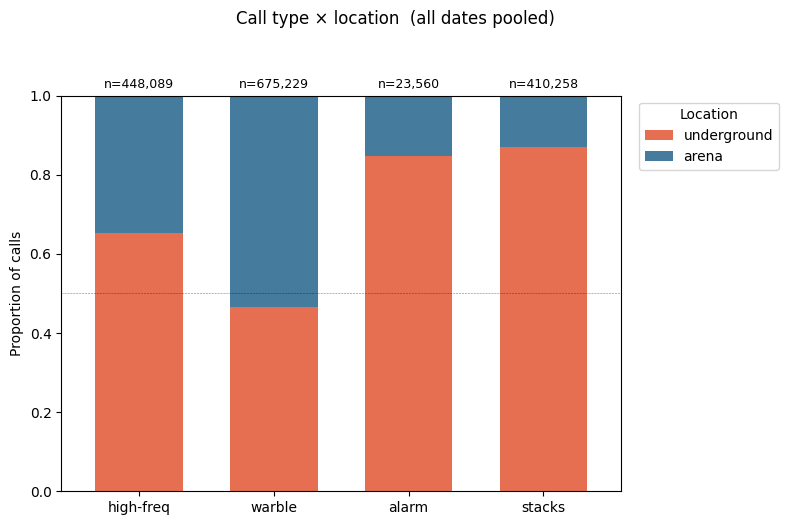

In [7]:
CALL_TYPE_ORDER = ["high-freq", "warble", "alarm", "stacks"]
LOCATION_ORDER  = ["underground", "arena"]      # underground first → goes at the bottom
LOC_COLORS      = ["#E76F51", "#457B9D"]        # match LOCATION_ORDER

df_all = pd.concat(
    [pd.read_parquet(PARQUET_DIR / f"all_calls_{d}.parquet") for d in DATES_TO_PLOT],
    ignore_index=True,
)
df_all["location"] = df_all["assigned_location"].replace(
    {"arena_1": "arena", "arena_2": "arena"}
)

props = (
    df_all.groupby(["event_type", "location"])
    .size()
    .unstack(fill_value=0)
    .reindex(CALL_TYPE_ORDER, fill_value=0)
    [LOCATION_ORDER]
)
totals = props.sum(axis=1)
props = props.div(totals, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
props.plot.bar(stacked=True, ax=ax, color=LOC_COLORS, width=0.65)

ax.set_ylabel("Proportion of calls")
ax.set_xlabel("")
ax.set_xticklabels(CALL_TYPE_ORDER, rotation=0)
ax.set_ylim(0, 1)
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.4, alpha=0.5)
ax.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")

# n_calls annotations above each bar.
for i, n in enumerate(totals):
    ax.text(i, 1.02, f"n={int(n):,}", ha="center", fontsize=9)

# Title placed higher so it doesn't overlap the n= annotations.
fig.suptitle("Call type × location  (all dates pooled)", y=1.04, fontsize=12)

fig.tight_layout()
save_fig(fig, "call_type_location_pooled")
plt.show()


In [ ]:
# Horizontal stacked bars per call type, ordered bottom-to-top: warble, stacks, alarm.
# (high-freq dropped per request.)
# Each call type has two bars (light, dark). Each bar sums to 1 within that
# period; underground sits on the left, above-ground stacked to its right.
# Color palette: earth-tone underground (browns), sky-tone above (blues).

CALL_TYPES = ["alarm", "stacks","warble"]   # bottom to top

COLORS = {
    ("underground", "light"): "#D7B89C",   # pale tan
    ("underground", "dark"):  "#3E2723",   # deep brown
    ("above",       "light"): "#BBDEFB",   # pale sky blue
    ("above",       "dark"):  "#0D47A1",   # deep navy
}

# Load all dates.
parts = []
for date_tag in DATES_TO_PLOT:
    parts.append(pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet"))
all_calls = pd.concat(parts, ignore_index=True)

all_calls["loc_2"] = all_calls["assigned_location"].map(LOC_GROUPS)

light_starts = all_calls["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[0])
light_ends   = all_calls["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[1])
hours = all_calls["start_time_real"].dt.hour
is_light = np.where(
    light_starts < light_ends,
    (hours >= light_starts) & (hours < light_ends),
    (hours >= light_starts) | (hours <  light_ends),
)
all_calls["light_dark"] = np.where(is_light, "light", "dark")


def compute_2x2(call_type):
    """2x2 col-normalized: rows [above, underground] x cols [light, dark]."""
    sub = all_calls[all_calls["event_type"] == call_type]
    counts = pd.crosstab(sub["loc_2"], sub["light_dark"]).reindex(
        index=["arena", "underground"], columns=["light", "dark"], fill_value=0
    )
    arr = counts.values.astype(float)
    col_sums = arr.sum(axis=0, keepdims=True)
    return np.divide(arr, col_sums, out=np.zeros_like(arr), where=col_sums > 0)


fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(CALL_TYPES))
height = 0.36

for i, ct in enumerate(CALL_TYPES):
    m = compute_2x2(ct)   # rows: [above, underground], cols: [light, dark]
    above_light, above_dark = m[0, 0], m[0, 1]
    under_light, under_dark = m[1, 0], m[1, 1]

    # Light bar (top of pair, lighter shades).
    y_light = y[i] + height/2
    ax.barh(y_light, under_light, height,
            color=COLORS[("underground", "light")], edgecolor="black", linewidth=0.5)
    ax.barh(y_light, above_light, height, left=under_light,
            color=COLORS[("above", "light")], edgecolor="black", linewidth=0.5)

    # Dark bar (bottom of pair, darker shades).
    y_dark = y[i] - height/2
    ax.barh(y_dark, under_dark, height,
            color=COLORS[("underground", "dark")], edgecolor="black", linewidth=0.5)
    ax.barh(y_dark, above_dark, height, left=under_dark,
            color=COLORS[("above", "dark")], edgecolor="black", linewidth=0.5)

    # Period sublabels just left of the y-axis.
    ax.text(-0.02, y_light, "light", ha="right", va="center", fontsize=8, color="#444")
    ax.text(-0.02, y_dark,  "dark",  ha="right", va="center", fontsize=8, color="#444")

ax.set_yticks(y)
ax.set_yticklabels([""] * len(CALL_TYPES))   # hide defaults; we add custom left-aligned text
ax.tick_params(axis="y", which="major", left=False, pad=0)

# Left-aligned call type labels (axes-x coords so all three line up).
for i, ct in enumerate(CALL_TYPES):
    ax.text(-0.20, y[i], ct, ha="left", va="center",
            fontsize=12, fontweight="bold",
            transform=ax.get_yaxis_transform())
ax.set_xlabel("Proportion of calls")
ax.set_xlim(0, 1.0)
ax.set_ylim(-0.5, len(CALL_TYPES) - 0.5 + 0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Clip the left spine to the bar region only (no extension up to the labels).
ax.spines["left"].set_bounds(-height, len(CALL_TYPES) - 1 + height)
ax.spines["bottom"].set_bounds(0, 1)

# Labels above the topmost bar — "underground" left-aligned at the bar's left edge,
# "above ground" right-aligned at the bar's right edge.
top_idx = len(CALL_TYPES) - 1
y_top_light = y[top_idx] + height/2
y_label = y_top_light + height/2 + 0.08
ax.text(0.0, y_label, "underground",
        ha="left",  va="bottom", fontsize=10, color="#3E2723", fontweight="bold")
ax.text(1.0, y_label, "above ground",
        ha="right", va="bottom", fontsize=10, color="#0D47A1", fontweight="bold")

fig.tight_layout()
save_fig(fig, "calls_stacked_light_dark_horizontal")
plt.show()


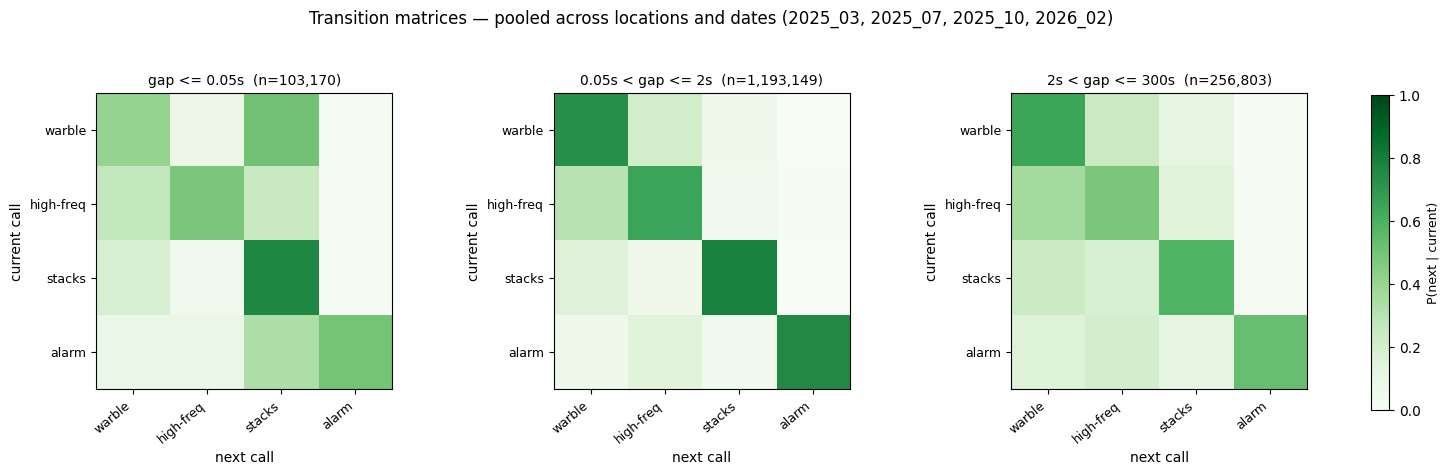

In [8]:
# Transition matrices like scripts/run_transitions.py, but with no
# above-ground vs underground split — all channels pooled, no light/dark split.

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from vocalization_analysis.calc_transitions import compute_arena_transitions

# Same band specs as run_transitions.py.
VERY_SHORT_GAP_SEC = 0.05
SHORT_GAP_SEC      = 2
LONG_GAP_SEC       = 300
CALL_TYPE_ORDER    = ["warble", "high-freq", "stacks", "alarm"]

# Pool calls across all dates.
parts = []
for date_tag in DATES_TO_PLOT:
    parts.append(pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet"))
calls = pd.concat(parts, ignore_index=True)

# Source key = (date, exp) — keeps transitions from spanning experiments.
exp_dfs = {f"{date}_{exp}": grp
           for (date, exp), grp in calls.groupby(["date_folder", "exp"])}

bands = [
    ("right", None,                VERY_SHORT_GAP_SEC, f"gap <= {VERY_SHORT_GAP_SEC}s"),
    ("mid",   VERY_SHORT_GAP_SEC,  SHORT_GAP_SEC,      f"{VERY_SHORT_GAP_SEC}s < gap <= {SHORT_GAP_SEC}s"),
    ("left",  SHORT_GAP_SEC,       LONG_GAP_SEC,       f"{SHORT_GAP_SEC}s < gap <= {LONG_GAP_SEC}s"),
]

# Compute matrices per band (the function returns arena + underground; we'll
# pool them ourselves to get a single matrix per band).
def compute_pooled(exp_dfs, lower, upper):
    res = compute_arena_transitions(
        exp_dfs,
        inter_call_interval_sec=upper,
        min_inter_call_interval_sec=lower,
        call_type_order=CALL_TYPE_ORDER,
    )
    counts = res["arena"]["counts"].add(res["underground"]["counts"], fill_value=0).astype(int)
    call_counts = res["arena"]["call_counts"].add(res["underground"]["call_counts"], fill_value=0).astype(int)
    probs = counts.div(counts.sum(axis=1), axis=0).fillna(0)
    return {"counts": counts, "call_counts": call_counts, "probabilities": probs}

matrices = {band: compute_pooled(exp_dfs, lower, upper) for band, lower, upper, _ in bands}

# Plot: 1 row x 3 cols (one per band), each a probability heatmap.
fig, axes = plt.subplots(1, len(bands), figsize=(5.0 * len(bands), 4.5))
if len(bands) == 1:
    axes = [axes]

for ax, (band_name, _, _, label) in zip(axes, bands):
    m = matrices[band_name]["probabilities"].values
    n_trans = int(matrices[band_name]["counts"].values.sum())

    im = ax.imshow(m, cmap="Greens", vmin=0, vmax=1)
    # for i in range(len(CALL_TYPE_ORDER)):
    #     for j in range(len(CALL_TYPE_ORDER)):
    #         txt_color = "white" if m[i, j] > 0.55 else "black"
    #         ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center",
    #                 fontsize=9, color=txt_color)

    ax.set_xticks(range(len(CALL_TYPE_ORDER)))
    ax.set_xticklabels(CALL_TYPE_ORDER, rotation=40, ha="right", fontsize=9)
    ax.set_yticks(range(len(CALL_TYPE_ORDER)))
    ax.set_yticklabels(CALL_TYPE_ORDER, fontsize=9)
    ax.set_title(f"{label}  (n={n_trans:,})", fontsize=10)
    ax.set_ylabel("current call", fontsize=10)
    ax.set_xlabel("next call", fontsize=10)

fig.suptitle(f"Transition matrices — pooled across locations and dates ({', '.join(DATES_TO_PLOT)})",
             fontsize=12, y=1.04)
fig.tight_layout()
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("P(next | current)", fontsize=9)
save_fig(fig, "transition_matrices_pooled_all_locations")
plt.show()


In [ ]:
# Talk version: only the middle band (0.05s < gap <= 2s) transition matrix,
# all labels sized for a presentation. Assumes the cell above has run
# (provides `matrices`, `bands`, `CALL_TYPE_ORDER`).

FS = 20

mid_band_name, _, _, mid_label = next(b for b in bands if b[0] == "mid")
m       = matrices[mid_band_name]["probabilities"].values
n_trans = int(matrices[mid_band_name]["counts"].values.sum())

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(m, cmap="Greens", vmin=0, vmax=1)

ax.set_xticks(range(len(CALL_TYPE_ORDER)))
ax.set_xticklabels(CALL_TYPE_ORDER, rotation=40, ha="right", fontsize=FS)
ax.set_yticks(range(len(CALL_TYPE_ORDER)))
ax.set_yticklabels(CALL_TYPE_ORDER, fontsize=FS)
ax.set_title(f"{mid_label}  (n={n_trans:,})", fontsize=FS, pad=20)
ax.set_ylabel("current call", fontsize=FS)
ax.set_xlabel("next call", fontsize=FS)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["0", "1"])
cbar.ax.tick_params(labelsize=FS)
cbar.set_label("P(next | current)", fontsize=FS)

fig.tight_layout()
save_fig(fig, "transition_matrix_mid_band_talk")
plt.show()


In [ ]:
# Newborn-call development in 2026_02. Litter was born overnight between
# 2026-03-01 and 2026-03-02 — day_in_experiment 13 is postnatal day 0.
# Calls before then are classifier false positives and get dropped.

BIRTH_DAY_IN_EXP = 13   # 2026-03-02 = postnatal day 0
BIN_MIN          = 10   # minutes per bin for the time-of-day curve

df = pd.read_parquet(PARQUET_DIR / "all_calls_2026_02.parquet")
nb_all = df[df["event_type"] == "newborn"].copy()
nb_all["age_days"] = nb_all["day_in_experiment"] - BIRTH_DAY_IN_EXP

n_false_pos = int((nb_all["age_days"] < 0).sum())
n_real      = int((nb_all["age_days"] >= 0).sum())
print(f"Pre-birth (false positives): {n_false_pos:,} calls")
print(f"Post-birth (real):           {n_real:,} calls")

nb = nb_all[nb_all["age_days"] >= 0].copy()
ages = sorted(nb["age_days"].unique())

per_age = (
    nb.groupby("age_days")["event_type"].size()
      .rename("n_calls")
      .reindex(ages, fill_value=0)
)

# Plot ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (1) Calls per postnatal day.
ax = axes[0]
ax.bar(per_age.index, per_age.values, color="#457B9D", edgecolor="white", linewidth=0.4)
ax.set_yscale("log")
ax.set_xlabel("Postnatal day (P0 = 2026-03-02)")
ax.set_ylabel("N newborn calls (log)")
ax.set_title("Calls per postnatal day")

# (2) Time-of-day pattern, one line per postnatal day, BIN_MIN-min bins.
ax = axes[1]
ts = nb["start_time_real"]
nb["bin_min"] = ((ts.dt.hour * 60 + ts.dt.minute) // BIN_MIN) * BIN_MIN

cmap = plt.get_cmap("viridis")
colors = [cmap(i / max(1, len(ages) - 1)) for i in range(len(ages))]

for age, color in zip(ages, colors):
    sub = nb[nb["age_days"] == age]
    counts = sub.groupby("bin_min").size()
    counts = counts.reindex(np.arange(0, 24 * 60, BIN_MIN), fill_value=0)
    ax.plot(counts.index / 60, counts.values, color=color, linewidth=1.2,
            label=f"P{int(age)}")

LIGHT_START, LIGHT_END = LIGHT_OVERRIDES.get("2026_02", LIGHT_DEFAULT)
if LIGHT_START < LIGHT_END:
    ax.axvspan(0, LIGHT_START, color="lightgray", alpha=0.3, zorder=0)
    ax.axvspan(LIGHT_END, 24,   color="lightgray", alpha=0.3, zorder=0)
else:
    ax.axvspan(LIGHT_END, LIGHT_START, color="lightgray", alpha=0.3, zorder=0)

ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel(f"N calls per {BIN_MIN}-min bin")
ax.set_title("Time-of-day pattern, by postnatal day")
ax.legend(fontsize=8, ncol=2, loc="upper right", title="age", frameon=False)

fig.suptitle(
    f"Newborn-call development, 2026_02 litter "
    f"(n={n_real:,} real, {n_false_pos:,} pre-birth false positives dropped)",
    fontsize=12, y=1.04,
)
fig.tight_layout()
save_fig(fig, "newborn_development_2026_02")
plt.show()


In [ ]:
# Newborn-call development in 2025_10. Birth day inferred from the previous
# cell's per-day plot: day_in_experiment 9 is postnatal day 0.
# Calls before then are classifier false positives and get dropped.

BIRTH_DAY_IN_EXP = 9
BIN_MIN          = 10

df = pd.read_parquet(PARQUET_DIR / "all_calls_2025_10.parquet")
nb_all = df[df["event_type"] == "newborn"].copy()
nb_all["age_days"] = nb_all["day_in_experiment"] - BIRTH_DAY_IN_EXP

n_false_pos = int((nb_all["age_days"] < 0).sum())
n_real      = int((nb_all["age_days"] >= 0).sum())
print(f"Pre-birth (false positives): {n_false_pos:,} calls")
print(f"Post-birth (real):           {n_real:,} calls")

nb = nb_all[nb_all["age_days"] >= 0].copy()
ages = sorted(nb["age_days"].unique())

per_age = (
    nb.groupby("age_days")["event_type"].size()
      .rename("n_calls")
      .reindex(ages, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (1) Calls per postnatal day.
ax = axes[0]
ax.bar(per_age.index, per_age.values, color="#457B9D", edgecolor="white", linewidth=0.4)
ax.set_yscale("log")
ax.set_xlabel(f"Postnatal day (P0 = day_in_experiment {BIRTH_DAY_IN_EXP})")
ax.set_ylabel("N newborn calls (log)")
ax.set_title("Calls per postnatal day")

# (2) Time-of-day pattern, one line per postnatal day, BIN_MIN-min bins.
ax = axes[1]
ts = nb["start_time_real"]
nb["bin_min"] = ((ts.dt.hour * 60 + ts.dt.minute) // BIN_MIN) * BIN_MIN

cmap = plt.get_cmap("viridis")
colors = [cmap(i / max(1, len(ages) - 1)) for i in range(len(ages))]

for age, color in zip(ages, colors):
    sub = nb[nb["age_days"] == age]
    counts = sub.groupby("bin_min").size()
    counts = counts.reindex(np.arange(0, 24 * 60, BIN_MIN), fill_value=0)
    ax.plot(counts.index / 60, counts.values, color=color, linewidth=1.2,
            label=f"P{int(age)}")

LIGHT_START, LIGHT_END = LIGHT_OVERRIDES.get("2025_10", LIGHT_DEFAULT)
if LIGHT_START < LIGHT_END:
    ax.axvspan(0, LIGHT_START, color="lightgray", alpha=0.3, zorder=0)
    ax.axvspan(LIGHT_END, 24,   color="lightgray", alpha=0.3, zorder=0)
else:
    ax.axvspan(LIGHT_END, LIGHT_START, color="lightgray", alpha=0.3, zorder=0)

ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel(f"N calls per {BIN_MIN}-min bin")
ax.set_title("Time-of-day pattern, by postnatal day")
ax.legend(fontsize=8, ncol=2, loc="upper right", title="age", frameon=False)

fig.suptitle(
    f"Newborn-call development, 2025_10 litter "
    f"(n={n_real:,} real, {n_false_pos:,} pre-birth false positives dropped)",
    fontsize=12, y=1.04,
)
fig.tight_layout()
save_fig(fig, "newborn_development_2025_10")
plt.show()


In [ ]:
# --- Acoustic helpers (cluster only — needs raw WAVs) ----------------------
# Map a call row to its per-channel concatenated WAV, slice out the call, and
# compute peak/median frequency from the magnitude spectrum.
import functools
import soundfile as sf

if HOST == "Linux":
    BASE_PROCESSED_AUDIO = Path("/mnt/home/neurostatslab/ceph/saneslab_data/gily_data/Processed_data/Audio")
else:
    BASE_PROCESSED_AUDIO = None  # raw WAVs aren't on the Mac

FREQ_BAND_HZ = (1_000, 60_000)  # gerbil-relevant; Nyquist at sr=125kHz is 62.5kHz

def call_wav_path(date_folder, exp, channel, file_num):
    if BASE_PROCESSED_AUDIO is None:
        raise RuntimeError("Raw WAVs aren't accessible on this platform.")
    return (BASE_PROCESSED_AUDIO / date_folder / str(int(exp))
            / "Averaged_wavs_w_annotations"
            / f"channel_{int(channel)}_file_{int(file_num):03d}.wav")

@functools.lru_cache(maxsize=256)
def _wav_samplerate(path_str):
    return sf.info(path_str).samplerate

def load_call_slice(date_folder, exp, channel, file_num, start_sec, stop_sec):
    p = call_wav_path(date_folder, exp, channel, file_num)
    sr = _wav_samplerate(str(p))
    start = int(round(start_sec * sr))
    stop  = int(round(stop_sec  * sr))
    y, _ = sf.read(str(p), start=start, stop=stop, dtype="float32", always_2d=False)
    return y, sr

def peak_and_median_freq(y, sr, band=FREQ_BAND_HZ):
    """Single-FFT peak and median frequency, restricted to `band` (Hz).
    median = freq at which cumulative spectral energy reaches 50%."""
    if len(y) < 16:
        return np.nan, np.nan
    y = y - y.mean()
    spec  = np.abs(np.fft.rfft(y * np.hanning(len(y))))
    freqs = np.fft.rfftfreq(len(y), 1 / sr)
    in_band = (freqs >= band[0]) & (freqs <= band[1])
    if not in_band.any() or spec[in_band].sum() == 0:
        return np.nan, np.nan
    f = freqs[in_band]
    s = spec[in_band]
    peak = f[np.argmax(s)]
    cum  = np.cumsum(s)
    median = f[np.searchsorted(cum, 0.5 * cum[-1])]
    return float(peak), float(median)


In [ ]:
# Peak / median frequency of newborn calls vs postnatal day.
# Set DATE_TAG to the dataset you want to analyze. Subsamples N_PER_DAY calls
# per postnatal day to keep runtime sane.

DATE_TAG         = "2025_10"            # try "2026_02" too
BIRTH_DAYS       = {"2025_10": 9, "2026_02": 13}
N_PER_DAY        = 200
NEWBORN_PROB_THR = 0.7                  # require meanprob_newborn >= this

birth_day = BIRTH_DAYS[DATE_TAG]

df = pd.read_parquet(PARQUET_DIR / f"all_calls_{DATE_TAG}.parquet")
nb = df[(df["event_type"] == "newborn") &
        (df["meanprob_newborn"] >= NEWBORN_PROB_THR)].copy()
nb["age_days"] = nb["day_in_experiment"] - birth_day
nb = nb[nb["age_days"] >= 0].reset_index(drop=True)
print(f"after thr {NEWBORN_PROB_THR}: {len(nb):,} confident newborn calls "
      f"({nb['age_days'].nunique()} postnatal days)")

sub = (
    nb.groupby("age_days", group_keys=False)
      .apply(lambda g: g.sample(min(len(g), N_PER_DAY), random_state=0))
      .reset_index(drop=True)
)
print(f"computing features for {len(sub):,} calls "
      f"(up to {N_PER_DAY}/day)...")

peaks   = np.empty(len(sub))
medians = np.empty(len(sub))
for i, row in enumerate(sub.itertuples(index=False)):
    y, sr = load_call_slice(row.date_folder, row.exp, row.channel,
                            row.file_num,
                            row.start_time_file_sec, row.stop_time_file_sec)
    peaks[i], medians[i] = peak_and_median_freq(y, sr)
    if (i + 1) % 500 == 0:
        print(f"  {i+1:,}/{len(sub):,}")
sub["peak_freq_hz"]   = peaks
sub["median_freq_hz"] = medians

agg = sub.groupby("age_days").agg(
    n        = ("peak_freq_hz",   "count"),
    peak_mean= ("peak_freq_hz",   "mean"),
    peak_std = ("peak_freq_hz",   "std"),
    med_mean = ("median_freq_hz", "mean"),
    med_std  = ("median_freq_hz", "std"),
).reset_index()
print(agg)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (mean_col, std_col, title) in zip(
    axes,
    [("peak_mean", "peak_std", "Peak frequency"),
     ("med_mean",  "med_std",  "Median frequency")],
):
    ax.errorbar(agg["age_days"], agg[mean_col] / 1000,
                yerr=agg[std_col] / 1000, fmt="o-", color="#457B9D",
                capsize=3, linewidth=1.5, markersize=5)
    ax.set_xlabel("Postnatal day")
    ax.set_ylabel("kHz")
    ax.set_title(f"{title}  (mean ± 1 std, n ≤ {N_PER_DAY}/day)")
    ax.grid(alpha=0.3)

fig.suptitle(
    f"Newborn calls {DATE_TAG} — acoustic features vs postnatal day "
    f"(meanprob_newborn ≥ {NEWBORN_PROB_THR})",
    y=1.02,
)
fig.tight_layout()
save_fig(fig, f"newborn_{DATE_TAG}_peak_median_freq_vs_age_thr{int(NEWBORN_PROB_THR*100)}")
plt.show()


In [ ]:
# --- Inspector: plot example newborn calls with their spectrogram + the
# 1D spectrum that peak_and_median_freq() actually used.
# Helps sanity-check whether the reported peak/median match the call's energy.

import librosa
import librosa.display

DATE_TAG         = "2025_10"     # which dataset
AGE_DAY          = 0             # postnatal day to sample examples from
N_EXAMPLES       = 6             # how many calls to display
NEWBORN_PROB_THR = 0.7           # require meanprob_newborn >= this
SEED             = 0

birth_day = BIRTH_DAYS[DATE_TAG]

df = pd.read_parquet(PARQUET_DIR / f"all_calls_{DATE_TAG}.parquet")
nb = df[(df["event_type"] == "newborn") &
        (df["meanprob_newborn"] >= NEWBORN_PROB_THR)].copy()
nb["age_days"] = nb["day_in_experiment"] - birth_day
pool = nb[nb["age_days"] == AGE_DAY]
if len(pool) == 0:
    raise SystemExit(f"No newborn calls at age P{AGE_DAY} in {DATE_TAG} "
                     f"with meanprob_newborn >= {NEWBORN_PROB_THR}.")
examples = pool.sample(min(N_EXAMPLES, len(pool)), random_state=SEED).reset_index(drop=True)
print(f"sampling {len(examples)} newborn calls from {DATE_TAG} P{AGE_DAY} "
      f"(meanprob_newborn ≥ {NEWBORN_PROB_THR})")

fig, axes = plt.subplots(len(examples), 2, figsize=(12, 2.6 * len(examples)),
                         gridspec_kw={"width_ratios": [2, 1]})
if len(examples) == 1:
    axes = np.array([axes])

for i, row in enumerate(examples.itertuples(index=False)):
    y, sr = load_call_slice(row.date_folder, row.exp, row.channel,
                            row.file_num,
                            row.start_time_file_sec, row.stop_time_file_sec)
    peak, median = peak_and_median_freq(y, sr)

    # --- Spectrogram (left)
    ax = axes[i, 0]
    n_fft = 512
    hop   = 128
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop, window="hann")
    Sdb = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    img = ax.imshow(
        Sdb,
        origin="lower",
        aspect="auto",
        extent=[0, len(y) / sr * 1000, 0, sr / 2 / 1000],  # ms, kHz
        cmap="magma",
        vmin=-80, vmax=0,
    )
    if not np.isnan(peak):
        ax.axhline(peak / 1000, color="cyan", linewidth=1.2, linestyle="-",
                   label=f"peak {peak/1000:.1f} kHz")
    if not np.isnan(median):
        ax.axhline(median / 1000, color="white", linewidth=1.0, linestyle="--",
                   label=f"median {median/1000:.1f} kHz")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.6)
    ax.set_ylim(0, sr / 2 / 1000)
    ax.set_ylabel("Frequency (kHz)")
    if i == len(examples) - 1:
        ax.set_xlabel("Time (ms)")
    ax.set_title(
        f"exp {row.exp}  file {int(row.file_num):03d}  ch {int(row.channel)}  "
        f"@ {row.start_time_file_sec:.2f}s  (dur {(row.stop_time_file_sec - row.start_time_file_sec)*1000:.0f} ms, "
        f"p_nb={row.meanprob_newborn:.2f})",
        fontsize=9, loc="left",
    )

    # --- 1D spectrum used by peak_and_median_freq (right)
    ax = axes[i, 1]
    yd = y - y.mean()
    spec  = np.abs(np.fft.rfft(yd * np.hanning(len(yd))))
    freqs = np.fft.rfftfreq(len(yd), 1 / sr) / 1000
    in_band = (freqs * 1000 >= FREQ_BAND_HZ[0]) & (freqs * 1000 <= FREQ_BAND_HZ[1])
    ax.plot(freqs, spec, color="black", linewidth=0.7, alpha=0.5,
            label="full")
    ax.plot(freqs[in_band], spec[in_band], color="#457B9D", linewidth=1.0,
            label=f"band {FREQ_BAND_HZ[0]/1000:.0f}-{FREQ_BAND_HZ[1]/1000:.0f} kHz")
    if not np.isnan(peak):
        ax.axvline(peak / 1000, color="red", linewidth=1.0, linestyle="-",
                   label=f"peak {peak/1000:.1f}")
    if not np.isnan(median):
        ax.axvline(median / 1000, color="orange", linewidth=1.0, linestyle="--",
                   label=f"median {median/1000:.1f}")
    ax.set_xlim(0, sr / 2 / 1000)
    ax.set_ylabel("|FFT|")
    if i == len(examples) - 1:
        ax.set_xlabel("Frequency (kHz)")
    ax.legend(loc="upper right", fontsize=7, framealpha=0.6)

fig.suptitle(f"Newborn-call inspector — {DATE_TAG} P{AGE_DAY}  "
             f"(p_nb ≥ {NEWBORN_PROB_THR}, band {FREQ_BAND_HZ[0]/1000:.0f}-{FREQ_BAND_HZ[1]/1000:.0f} kHz)",
             y=1.005, fontsize=12)
fig.tight_layout()
plt.show()


In [ ]:
# Newborn call RATE per postnatal day. Rate = confident-newborn calls per
# cage-hour, where cage-hours = (unique (exp, file_num) pairs) × FILE_MIN / 60.
# Each WAV is ~6 minutes, so file-count is a silence-robust recording-duration
# proxy. Multi-experiment days sum additively (one calendar hour with two
# cages running = 2 cage-hours).

DATE_TAG         = "2026_02"
BIRTH_DAYS       = {"2025_10": 9, "2026_02": 13}
NEWBORN_PROB_THR = 0.7
FILE_MIN         = 6.0   # nominal WAV duration in minutes

birth_day = BIRTH_DAYS[DATE_TAG]

df = pd.read_parquet(PARQUET_DIR / f"all_calls_{DATE_TAG}.parquet").copy()
df["age_days"] = df["day_in_experiment"] - birth_day
df = df[df["age_days"] >= 0]

# Cage-hours per day: unique (exp, file_num) pairs × FILE_MIN / 60.
cage_hours = (
    df[["age_days", "exp", "file_num"]]
      .drop_duplicates()
      .groupby("age_days").size()
      .rename("n_files") * FILE_MIN / 60.0
).rename("cage_hours")

nb_counts = (
    df[(df["event_type"] == "newborn") &
       (df["meanprob_newborn"] >= NEWBORN_PROB_THR)]
      .groupby("age_days").size()
      .rename("newborn_calls")
)

rate = pd.concat([cage_hours, nb_counts], axis=1).fillna(0)
rate["rate_per_cage_hour"] = (
    rate["newborn_calls"] / rate["cage_hours"].replace(0, np.nan)
)
print(rate)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(rate.index, rate["rate_per_cage_hour"], color="#457B9D",
       edgecolor="white", linewidth=0.4)
ax.set_xlabel("Postnatal day")
ax.set_ylabel("Confident-newborn calls per cage-hour")
ax.set_title(
    f"Newborn call rate vs postnatal day — {DATE_TAG} "
    f"(p_nb ≥ {NEWBORN_PROB_THR})"
)
ax.grid(alpha=0.3, axis="y")

ymax = float(rate["rate_per_cage_hour"].max())
for x, h in zip(rate.index, rate["cage_hours"]):
    ax.text(x, rate.loc[x, "rate_per_cage_hour"] + ymax * 0.02,
            f"{h:.1f}", ha="center", fontsize=8, color="dimgray")

fig.tight_layout()
save_fig(fig, f"newborn_{DATE_TAG}_rate_vs_age_thr{int(NEWBORN_PROB_THR*100)}")
plt.show()


In [ ]:
# Newborn call RATE per postnatal day, split into LIGHT vs DARK.
# Rate per period = confident-newborn calls in that period
#                   / cage-hours recorded in that period.
# Cage-hours via the file-count proxy: unique (exp, file_num, period) pairs
# × FILE_MIN / 60. A WAV that straddles the light/dark boundary is counted
# in both periods (slight overcount, tiny in practice).

DATE_TAG         = "2026_02"
BIRTH_DAYS       = {"2025_10": 9, "2026_02": 13}
NEWBORN_PROB_THR = 0.7
FILE_MIN         = 6.0

birth_day = BIRTH_DAYS[DATE_TAG]
light_start, light_end = LIGHT_OVERRIDES.get(DATE_TAG, LIGHT_DEFAULT)

df = pd.read_parquet(PARQUET_DIR / f"all_calls_{DATE_TAG}.parquet").copy()
df["age_days"] = df["day_in_experiment"] - birth_day
df = df[df["age_days"] >= 0].copy()

hours = df["start_time_real"].dt.hour
if light_start < light_end:
    is_light = (hours >= light_start) & (hours < light_end)
else:
    is_light = (hours >= light_start) | (hours < light_end)
df["period"] = np.where(is_light, "light", "dark")

cage_hours = (
    df[["age_days", "period", "exp", "file_num"]]
      .drop_duplicates()
      .groupby(["age_days", "period"]).size()
      .unstack(fill_value=0)
) * FILE_MIN / 60.0

nb_counts = (
    df[(df["event_type"] == "newborn") &
       (df["meanprob_newborn"] >= NEWBORN_PROB_THR)]
      .groupby(["age_days", "period"]).size()
      .unstack(fill_value=0)
)

ages = sorted(df["age_days"].unique())
for col in ("light", "dark"):
    if col not in cage_hours.columns: cage_hours[col] = 0
    if col not in nb_counts.columns:  nb_counts[col]  = 0
cage_hours = cage_hours.reindex(ages, fill_value=0)[["light", "dark"]]
nb_counts  = nb_counts.reindex(ages, fill_value=0)[["light", "dark"]]

rate = nb_counts.div(cage_hours.replace(0, np.nan))
print("cage_hours per (age, period):"); print(cage_hours.round(2))
print("\nnewborn calls per (age, period):"); print(nb_counts)
print("\nrate (calls/cage-hour):"); print(rate.round(2))

PERIOD_COLORS = {"light": "#F2C94C", "dark": "#2D3142"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
ymax = float(np.nanmax(rate.values)) if np.isfinite(np.nanmax(rate.values)) else 1.0

for ax, period in zip(axes, ["light", "dark"]):
    ax.bar(ages, rate[period], color=PERIOD_COLORS[period],
           edgecolor="white", linewidth=0.4)
    for age in ages:
        r = rate.loc[age, period]
        h = cage_hours.loc[age, period]
        if not np.isnan(r):
            ax.text(age, r + ymax * 0.02, f"{h:.1f}",
                    ha="center", fontsize=8, color="dimgray")
    ax.set_xlabel("Postnatal day")
    ax.set_title(f"{period}  (light window {light_start:02d}:00–{light_end:02d}:00)")
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("Confident-newborn calls per cage-hour")
fig.suptitle(
    f"Newborn call rate vs postnatal day, light vs dark — {DATE_TAG} "
    f"(p_nb ≥ {NEWBORN_PROB_THR})",
    y=1.02,
)
fig.tight_layout()
save_fig(fig, f"newborn_{DATE_TAG}_rate_vs_age_light_dark_thr{int(NEWBORN_PROB_THR*100)}")
plt.show()


## Do gerbils stop chatting in the nest when someone alarms?

For each alarm bout (≥ 5 alarm calls within 2 s gaps), measure the rate of
**non-alarm** calls in the nest (`underground`) in a window around the bout's
start: `[-5 s, +10 s]`. Each alarm bout → one thin line; the mean across bouts
is overlaid in red.

In [ ]:
# Non-alarm nest call rate around alarm-bout onsets.
from vocalization_analysis.bouts import detect_alarm_scales, summarize_scale

DATE_TAG_BOUTS = "2025_10"
NEST_LOC       = "underground"   # only location considered "in nest"
WIN_PRE_S      = 5.0             # seconds before bout start
WIN_POST_S     = 10.0            # seconds after bout start
BIN_S          = 0.5             # rate bin width (s); rate = count / BIN_S (Hz)

df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{DATE_TAG_BOUTS}.parquet")

# 1. Detect alarm bouts (bout scope: same date/exp/location, gap ≤ 2 s, ≥ 5 calls).
df_alarm = df_d[df_d["event_type"] == "alarm"].copy()
df_alarm = detect_alarm_scales(df_alarm)
bouts_meta = summarize_scale(df_alarm, prefix="bout")
alarm_bouts = bouts_meta[bouts_meta["bout_kind"] == "in_bout"].copy()
print(f"{len(alarm_bouts)} alarm bouts in {DATE_TAG_BOUTS}")

# 2. Non-alarm nest calls only.
nest_non_alarm = df_d[(df_d["assigned_location"] == NEST_LOC) &
                      (df_d["event_type"] != "alarm")]
nest_times = nest_non_alarm["start_time_real"].sort_values().values

# 3. For each alarm bout, histogram of non-alarm-nest-call onsets in
#    [t0 - WIN_PRE_S, t0 + WIN_POST_S], converted to rate (Hz).
edges_s = np.arange(-WIN_PRE_S, WIN_POST_S + BIN_S / 2, BIN_S)
centers_s = (edges_s[:-1] + edges_s[1:]) / 2

curves = np.empty((len(alarm_bouts), len(centers_s)), dtype=float)
for i, t0 in enumerate(alarm_bouts["start_time"].values):
    lo = t0 - np.timedelta64(int(WIN_PRE_S * 1e9), "ns")
    hi = t0 + np.timedelta64(int(WIN_POST_S * 1e9), "ns")
    lo_i = np.searchsorted(nest_times, lo, side="left")
    hi_i = np.searchsorted(nest_times, hi, side="right")
    rel_s = (nest_times[lo_i:hi_i] - t0) / np.timedelta64(1, "s")
    counts, _ = np.histogram(rel_s, bins=edges_s)
    curves[i] = counts / BIN_S

# 4. Plot: one thin line per bout, mean overlaid.
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(curves.shape[0]):
    ax.plot(centers_s, curves[i], color="#457B9D", alpha=0.12, linewidth=0.6)
mean_curve = curves.mean(axis=0)
ax.plot(centers_s, mean_curve, color="#E63946", linewidth=2.2,
        label=f"mean (n={curves.shape[0]} bouts)")
ax.axvline(0, color="black", linestyle="--", linewidth=0.8, label="alarm bout start")
ax.set_xlabel("Time relative to alarm bout start (s)")
ax.set_ylabel(f"Non-alarm nest call rate (Hz, {BIN_S}s bins)")
ax.set_title(f"{DATE_TAG_BOUTS}: nest call rate around alarm bout onset")
ax.set_xlim(-WIN_PRE_S, WIN_POST_S)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()
save_fig(fig, f"nest_call_rate_around_alarm_{DATE_TAG_BOUTS}")